# RLSSM Simulators: Advanced Tutorial

This is the **advanced** companion to the
[RLSSM beginner tutorial](rlssm_tutorial.ipynb). The beginner tutorial showed the
standard path: choose a preset, simulate data, plot the basic learning pattern, validate
the data, and inspect the HSSM handoff. Here we slow down and open the machinery.

The goal is not just to show more API calls. The goal is to explain how the pieces fit
together so you can safely build non-standard RLSSMs:

1. **Response labels vs. learning choices**: how SSM choices become RL choice indices.
2. **Component swapping**: dual-learning-rate learners, Gaussian rewards, and
   `TaskConfig` shorthand.
3. **Custom task environments**: the task-side protocol, RNG lifecycle, context output
   columns, and a reversal-bandit example.
4. **Custom learning processes**: the explicit-state Python interface, why
   `compute_python` and `update_python` are the template methods, and how JAX versions
   fit the inference path.
5. **Participant-wise parameters**: full scalar/list rules for per-participant `theta`.
6. **Posterior predictive simulation**: `mode="ppc"` as observed-history-conditioned
   simulation.
7. **Validation and inference internals**: `validate_data`, `CompiledModel`, and the
   HSSM bridge.

> **Dependency note.** Executed cells require only `ssm-simulators`, NumPy, pandas, and
> matplotlib. JAX-specific examples are guarded so the tutorial still runs without the
> optional `[jax]` extra. HSSM handoff code is shown illustratively in markdown because
> HSSM is a separate package.


## Setup

We reuse one baseline model and one parameter dictionary throughout. The model is the
built-in `2AB_RW_Angle` preset: a two-armed Bernoulli bandit, a Rescorla-Wagner learning
rule, and an angle SSM decision process.

Think of `base_config` as the **model structure** and `theta` as the **concrete numeric
values** used for one simulation or inference run. Keeping those separate is central to
`ssms.rl`: a `ModelConfig` says what the model is, while `theta` says which participant
or group parameters to simulate with.


In [1]:
import ssms.rl as rl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

# Baseline model + parameters reused across the tutorial.
base_config = rl.preset.get("2AB_RW_Angle")
theta = {
    "rl_alpha": 0.3,
    "scaler": 2.0,
    "a": 1.5,
    "z": 0.5,
    "t": 0.3,
    "theta": 0.2,
}

# A small valid dataset we reuse for PPC, validation, and bridge sections.
data = rl.Simulator(base_config).simulate(
    theta=theta, n_trials=60, n_participants=5, random_state=42
)
data.head()


,participant_id,trial_id,rt,response,feedback
0,0,0,2.999996,1,0.0
1,0,1,1.506524,-1,0.0
2,0,2,1.080149,-1,0.0
3,0,3,1.355910,-1,1.0
4,0,4,1.051847,-1,0.0


## 0. How the simulator pieces fit together

Before diving into individual features, it helps to have a whole-system picture.
`ssms.rl` is organized around three object families:

- **`ModelConfig`** stores structure: which decision process, which learning process,
  which task environment, response/choice mapping, parameter lists, bounds, defaults,
  context-field contract, and backend/gradient policy.
- **`Simulator`** executes the trial loop: compute learning-derived SSM parameters,
  run one SSM trial, map the response label to an choice index, sample feedback, update
  learning state, and record a DataFrame row.
- **`CompiledModel`** exposes the same model in a form downstream inference tools can
  consume: metadata plus participant-wise computed-parameter functions.

The diagram below is not a separate API. It is a visual map of the objects you will use
in the rest of the tutorial.


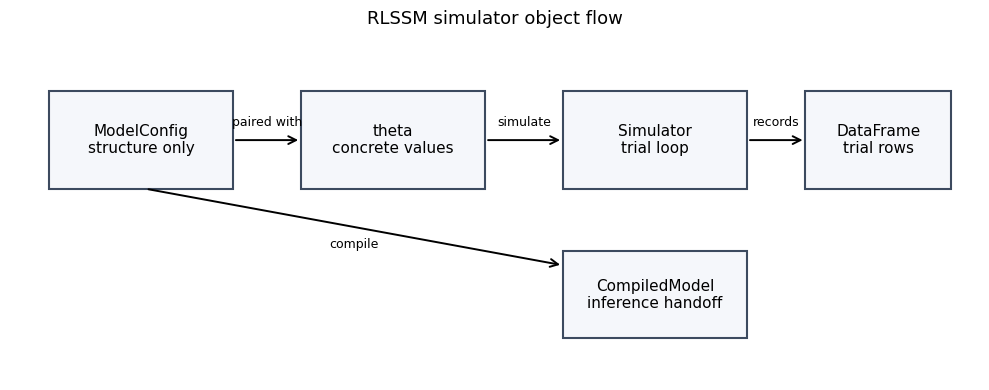

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

boxes = [
    (0.04, 0.55, 0.19, 0.28, "ModelConfig\nstructure only"),
    (0.30, 0.55, 0.19, 0.28, "theta\nconcrete values"),
    (0.57, 0.55, 0.19, 0.28, "Simulator\ntrial loop"),
    (0.57, 0.12, 0.19, 0.25, "CompiledModel\ninference handoff"),
    (0.82, 0.55, 0.15, 0.28, "DataFrame\ntrial rows"),
]

for x, y, w, h, label in boxes:
    ax.add_patch(Rectangle((x, y), w, h, fc="#f5f7fb", ec="#3c4a5f", lw=1.5))
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=11)

def arrow(start, end, text=None, yoff=0.0):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=14, lw=1.4))
    if text:
        ax.text((start[0] + end[0]) / 2, (start[1] + end[1]) / 2 + yoff, text,
                ha="center", va="center", fontsize=9)

arrow((0.23, 0.69), (0.30, 0.69), "paired with", 0.05)
arrow((0.49, 0.69), (0.57, 0.69), "simulate", 0.05)
arrow((0.76, 0.69), (0.82, 0.69), "records", 0.05)
arrow((0.14, 0.55), (0.57, 0.33), "compile", -0.05)

ax.set_title("RLSSM simulator object flow", fontsize=13)
plt.tight_layout()
plt.show()


## 1. Response labels vs. learning choices

This is the most important advanced idea, because it is where the SSM world and the RL
world meet.

- The **decision process** emits a **response label**. For common two-choice SSMs in
  this package, the labels are often `-1` and `1` because that is how the underlying SSM
  simulator encodes the two response boundaries.
- The **learning process** and **task environment** use **zero-based choice indices**:
  `0, 1, ..., n_arms - 1`. A bandit with two arms samples feedback for choice `0` or
  choice `1`, not for response label `-1` or `1`.

So every non-omission trial has a translation step:

```text
SSM response label -> learning choice index -> task context -> learning update
```

The public data keeps the SSM response label in `response`. If you want to inspect the
derived choice index, set `include_choice=True` on `ModelConfig`.


In [ ]:
labeled = rl.ModelConfig(
    model_name="labeled",
    description="Expose both response label and choice index",
    decision_process="angle",
    learning_process=rl.learning.RescorlaWagnerDeltaRule(),
    task_environment=rl.env.Bandit.bernoulli(
        probabilities=[0.7, 0.3], response_labels=[-1, 1]
    ),
    include_choice=True,
)

d = rl.Simulator(labeled).simulate(theta=theta, n_trials=8, n_participants=1, random_state=0)
print("response -> choice mapping:", labeled.response_to_choice)
d[["trial_id", "response", "choice", "feedback"]]


By default, `response_to_choice="auto"`. Auto mapping pairs labels with choice indices in
the order supplied by the task environment. For `response_labels=[-1, 1]`, this means
`{-1: 0, 1: 1}`. This default is usually what you want when the first label corresponds
to the first task arm, the second label to the second task arm, and so on.

An explicit mapping is useful when the SSM labels have the opposite meaning in your
experiment, or when you want to make the semantics impossible to miss in code.


In [ ]:
reversed_map = rl.ModelConfig(
    model_name="reversed",
    description="Custom, reversed response-to-choice mapping",
    decision_process="angle",
    learning_process=rl.learning.RescorlaWagnerDeltaRule(),
    task_environment=rl.env.Bandit.bernoulli(
        probabilities=[0.7, 0.3], response_labels=[-1, 1]
    ),
    response_to_choice={-1: 1, 1: 0},   # flip which arm each label updates
)
reversed_map.response_to_choice


The config validates the mapping immediately. The keys must cover exactly the response
labels, and the values must be unique choice indices from `0` to `n_arms - 1`. This
matters because an incomplete or ambiguous mapping would update the wrong Q-value or
sample rewards from the wrong arm.


In [ ]:
try:
    rl.ModelConfig(
        model_name="bad_mapping",
        description="Demonstrate invalid response-to-choice mapping",
        decision_process="angle",
        learning_process=rl.learning.RescorlaWagnerDeltaRule(),
        task_environment=rl.env.Bandit.bernoulli(
            probabilities=[0.7, 0.3], response_labels=[-1, 1]
        ),
        response_to_choice={-1: 0},  # missing label 1
    )
except ValueError as err:
    print(err)


In [ ]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.axis("off")
steps = [
    ("SSM", "response = -1 or 1"),
    ("Mapping", "response_to_choice"),
    ("Task", "sample_context(context)"),
    ("Learning", "update Q[choice]"),
    ("Next trial", "compute v from Q"),
]
xs = np.linspace(0.08, 0.86, len(steps))
for x, (title, body) in zip(xs, steps):
    ax.add_patch(Rectangle((x, 0.35), 0.14, 0.28, fc="#fff7e8", ec="#9a6b16", lw=1.2))
    ax.text(x + 0.07, 0.52, title, ha="center", va="center", fontweight="bold")
    ax.text(x + 0.07, 0.43, body, ha="center", va="center", fontsize=9)
for x0, x1 in zip(xs[:-1], xs[1:]):
    ax.add_patch(FancyArrowPatch((x0 + 0.14, 0.49), (x1, 0.49), arrowstyle="->", mutation_scale=12))
ax.set_title("How one trial passes information between components", fontsize=12)
plt.tight_layout()
plt.show()


## 2. Swapping in different built-in components

The three pillars are deliberately independent. You can swap the learning process,
reward distribution, or task-construction shorthand while keeping the same decision
process. `ModelConfig` handles the handshake: it derives required parameters, validates
response labels, and checks that the learning process computes SSM parameters the
decision process actually needs.


### A dual-learning-rate learner

`RescorlaWagnerDualAlphaRule` uses separate learning rates for positive and negative
prediction errors:

- `rl_alpha` updates Q-values when the outcome is better than expected.
- `rl_alpha_neg` updates Q-values when the outcome is worse than expected.

This is useful for modeling asymmetric learning: for example, participants who learn
quickly from rewards but slowly from disappointments, or the reverse. The decision
process is unchanged; only the learning process has one extra free parameter.


In [7]:
dual = rl.learning.RescorlaWagnerDualAlphaRule()
print("free params:", dual.free_params)

dual_config = rl.ModelConfig(
    model_name="dual_alpha",
    description="Asymmetric Rescorla-Wagner learner",
    decision_process="angle",
    learning_process=dual,
    task_environment=rl.env.Bandit.bernoulli(probabilities=[0.7, 0.3], response_labels=[-1, 1]),
)
theta_dual = {**theta, "rl_alpha_neg": 0.1}  # learn less from negative outcomes
rl.Simulator(dual_config).simulate(theta=theta_dual, n_trials=5, n_participants=1, random_state=0).head()


free params: ['rl_alpha', 'rl_alpha_neg', 'scaler']


,participant_id,trial_id,rt,response,feedback
0,0,0,0.752191,1,0.0
1,0,1,3.762216,-1,0.0
2,0,2,2.644401,1,0.0
3,0,3,1.402577,1,0.0
4,0,4,1.131324,-1,0.0


### Continuous Gaussian rewards

Bandits are not limited to binary `0`/`1` feedback. `Bandit.gaussian(...)` draws
continuous rewards from per-arm normal distributions. The learning rule sees the same
kind of value update, but now the reward can be any real number sampled from the chosen
arm's distribution.


In [8]:
gaussian_config = rl.ModelConfig(
    model_name="gaussian_reward",
    description="Continuous Gaussian rewards",
    decision_process="angle",
    learning_process=rl.learning.RescorlaWagnerDeltaRule(),
    task_environment=rl.env.Bandit.gaussian(
        means=[1.0, 0.0], sds=[0.5, 0.5], response_labels=[-1, 1]
    ),
)
g = rl.Simulator(gaussian_config).simulate(theta=theta, n_trials=8, n_participants=1, random_state=0)
g[["trial_id", "response", "feedback"]]


,trial_id,response,feedback
0,0,1,-0.447973
1,1,-1,1.367978
2,2,-1,1.426691
3,3,-1,1.080474
4,4,-1,1.402828
5,5,-1,1.108784
6,6,-1,0.630443
7,7,-1,1.296739


### The `TaskConfig` shorthand

For registered built-in tasks, `TaskConfig` is a compact way to describe the task. It is
not a different simulator path: `ModelConfig` resolves the `TaskConfig` into an actual
`TaskEnvironment` during construction.

Use `TaskConfig` when you want a concise configuration or when you are building configs
programmatically. Use direct environment constructors when you want the object and its
parameters to be visually explicit.


In [9]:
shorthand_config = rl.ModelConfig(
    model_name="shorthand",
    description="Task built from a TaskConfig",
    decision_process="angle",
    learning_process=rl.learning.RescorlaWagnerDeltaRule(),
    task_environment=rl.env.TaskConfig(
        task="bandit",
        reward="gaussian",
        means=[1.0, 0.0],
        sds=[0.5, 0.5],
        response_labels=[-1, 1],
    ),
)
type(shorthand_config.task_environment).__name__


'Bandit'

## 3. Writing your own task environment

A task environment is the simulator's model of the external task. It answers questions
like: how many arms exist, which SSM response labels correspond to those arms, which
observable context fields should be recorded, and what feedback/context should be
available after a choice.

A custom environment implements the `rl.env.TaskEnvironment` protocol:

| Member | Role | Who uses it? |
|---|---|---|
| `n_arms` | Number of zero-based learning choices. | `ModelConfig` checks compatibility with the learner. |
| `response_labels` | SSM labels corresponding to choices in order. | `ModelConfig` builds/validates `response_to_choice`. |
| `context_fields` | Observable context column names. | `Simulator`, `validate_data`, and `CompiledModel` know which columns to expect. |
| `reset(rng)` | Reset state for a new participant. | `Simulator` calls once per participant. |
| `get_trial_context(trial_idx)` | Return pre-decision context columns for the row. | Passed to learning before the SSM trial. |
| `sample_context(context, trial_idx)` | Return post-decision context such as feedback. | Called after each non-omission SSM choice. |

The key convention is that `sample_context` receives a context dictionary that already
contains the zero-based `choice`, not just the raw SSM response label.


### Example: a reversal bandit

The environment below is a two-armed Bernoulli bandit whose better arm flips halfway
through the session. It demonstrates three common custom-environment patterns:

- **RNG lifecycle:** `reset(rng)` stores the participant-specific random generator. This
  keeps simulations reproducible and gives each participant an independent random
  stream.
- **Trial-dependent design:** `_probs(trial_idx)` changes reward probabilities across
  time.
- **Extra output columns:** `get_extra_data` records `best_arm`, which can later be used
  for plots, validation, or as an empirical design column.


In [ ]:
class ReversalBandit:
    """Two-armed Bernoulli bandit whose best arm flips at `reversal_at`."""

    def __init__(self, p_high=0.8, response_labels=(-1, 1), reversal_at=40):
        self.p_high = float(p_high)
        self._labels = list(response_labels)
        self.reversal_at = int(reversal_at)
        self._rng = None

    @property
    def n_arms(self):
        return 2

    @property
    def response_labels(self):
        return list(self._labels)

    @property
    def context_fields(self):
        return ["best_arm", "feedback"]

    def reset(self, rng=None):
        self._rng = rng or np.random.default_rng()

    def _probs(self, trial_idx):
        hi = self.p_high
        return [hi, 1 - hi] if trial_idx < self.reversal_at else [1 - hi, hi]

    def get_trial_context(self, trial_idx):
        return {"best_arm": float(int(np.argmax(self._probs(trial_idx))))}

    def sample_context(self, context, trial_idx):
        if self._rng is None:
            raise RuntimeError("call reset() before sample_context()")
        choice = int(context["choice"])
        feedback = float(self._rng.random() < self._probs(trial_idx)[choice])
        return {"feedback": feedback}


print("is a TaskEnvironment:", isinstance(ReversalBandit(), rl.env.TaskEnvironment))


In [ ]:
reversal_config = rl.ModelConfig(
    model_name="reversal_bandit_demo",
    description="RW learner + angle SSM + custom reversal bandit",
    decision_process="angle",
    learning_process=rl.learning.RescorlaWagnerDeltaRule(),
    task_environment=ReversalBandit(p_high=0.85, response_labels=(-1, 1), reversal_at=40),
    include_choice=True,
)

reversal_data = rl.Simulator(reversal_config).simulate(
    theta=theta, n_trials=80, n_participants=20, random_state=11
)
reversal_data.head()


In [ ]:
reversal_summary = (
    reversal_data.assign(chose_best=lambda df: df["choice"] == df["best_arm"])
    .groupby("trial_id")
    .agg(best_arm=("best_arm", "first"), p_choose_best=("chose_best", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].step(reversal_summary["trial_id"], reversal_summary["best_arm"], where="post", color="C4")
axes[0].set_ylabel("Best arm")
axes[0].set_yticks([0, 1])
axes[0].set_title("Custom reversal-bandit design")

axes[1].plot(reversal_summary["trial_id"], reversal_summary["p_choose_best"], color="C0")
axes[1].axhline(0.5, color="gray", ls="--", lw=1)
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("P(choose current best arm)")
axes[1].set_ylim(0, 1)
axes[1].set_title("Behavior adapts after the reversal")

plt.tight_layout()
plt.show()


## 4. Writing your own learning process

A learning process is the simulator's model of internal state. For a Rescorla-Wagner
learner, the state is Q-values. For other models, it could be working-memory contents,
habit strengths, uncertainty estimates, eligibility traces, or anything else your model
needs.

The learning process has two jobs:

1. **Declare its contract** so `ModelConfig`, `Simulator`, `CompiledModel`, and HSSM know
   what parameters, computed decision-process outputs, and required context fields exist.
2. **Implement state transitions** so the simulator can compute SSM parameters before a
   trial and update learning state after observing trial context.

The explicit-state methods are the main template:

```python
def init_state(self) -> dict[str, Any]
def compute_python(self, state: dict[str, Any], params: dict[str, float], context: dict[str, Any]) -> dict[str, float]
def update_python(self, state: dict[str, Any], params: dict[str, float], context: dict[str, Any]) -> dict[str, Any]
```

`context` is the per-trial information channel. It can include runtime fields such as
`response`, `choice`, and `rt`, plus task/data fields such as `feedback`, `condition`,
`block`, or `stimulus_id`.

`compute_python` and `update_python` are separated because RLSSM order matters:
computed SSM parameters for trial `t` must be based on the learning state before trial
`t` feedback is incorporated.


### LearningProcess metadata

The metadata properties are not decoration. They are how the learning process connects
to the rest of the model.

| Property | Meaning | Consumed by |
|---|---|---|
| `computed_params` | Learning/control outputs, e.g. `['v']` or `['drift', 'threshold']`. | `ModelConfig` handshake and `CompiledModel` output. |
| `free_params` | Learning parameters required from `theta`, e.g. `['rl_alpha', 'scaler']`. | `Simulator`, `CompiledModel`, HSSM bridge. |
| `param_bounds` | Bounds for learning parameters. | Config metadata, validation, HSSM handoff. |
| `default_params` | Defaults for learning parameters. | Preset/spec display and bridge metadata. |
| `required_context_fields` | Context keys the learning rule needs, such as `choice` and `feedback`. | `ModelConfig`, `Simulator`, `CompiledModel`. |
| `available_backends` | Which implementations exist, usually `('python',)` or `('python', 'jax')`. | Backend resolution. |
| `supports_gradient` | Whether the JAX backend is differentiable enough for gradient inference. | `CompiledModel` and HSSM bridge. |
| `n_actions` | Optional choice-count compatibility check. | `ModelConfig.validate()`. |

The simulator can run a Python-only learner. HSSM gradient-based inference generally
requires a JAX-capable learner with `supports_gradient=True`.


### A fully commented Python learner

The class below is intentionally verbose. It implements the same basic update as the
built-in `RescorlaWagnerDeltaRule`, but spells out each role.

Implementation guidance:

- Treat `state` as immutable input: copy arrays before changing them, then return a new
  state dictionary.
- Use `params` only for model parameters declared in `free_params`.
- Return a dictionary from `compute_python` whose keys match `computed_params`; use
  `computed_param_mapping` on `ModelConfig` when learning-output names differ from SSM
  parameter names.
- Use `context["choice"]` and `context["feedback"]` in `update_python`; do not try to
  decode SSM response labels inside the learning process.
- Legacy `reset`, `compute_ssm_params`, and `update` wrappers are included here so
  `isinstance(obj, rl.learning.LearningProcess)` is true and older inspection patterns
  still work. The simulator and compiled model use the explicit-state methods when
  available.


In [ ]:
class SimpleRW:
    """Teaching implementation of a two-choice Rescorla-Wagner learner."""

    n_actions = 2
    required_context_fields = ["choice", "feedback"]

    def __init__(self, initial_q=0.5):
        self.initial_q = float(initial_q)
        self._state = None

    @property
    def computed_params(self):
        return ["v"]

    @property
    def free_params(self):
        return ["rl_alpha", "scaler"]

    @property
    def param_bounds(self):
        return {"rl_alpha": (0.0, 1.0), "scaler": (0.001, 10.0)}

    @property
    def default_params(self):
        return {"rl_alpha": 0.2, "scaler": 2.0}

    @property
    def available_backends(self):
        return ("python",)

    @property
    def supports_gradient(self):
        return False

    def init_state(self):
        return {"q_values": np.full(self.n_actions, self.initial_q, dtype=np.float64)}

    def compute_python(self, state, params, context):
        q_values = state["q_values"]
        drift = (q_values[1] - q_values[0]) * params["scaler"]
        return {"v": float(drift)}

    def update_python(self, state, params, context):
        q_values = np.asarray(state["q_values"], dtype=np.float64).copy()
        choice = int(context["choice"])
        feedback = float(context["feedback"])
        prediction_error = feedback - q_values[choice]
        q_values[choice] += params["rl_alpha"] * prediction_error
        return {"q_values": q_values}

    # Legacy wrappers for protocol/runtime compatibility.
    def reset(self, **kwargs):
        self._state = self.init_state()

    def compute_ssm_params(self, trial_params):
        if self._state is None:
            raise RuntimeError("call reset() before compute_ssm_params()")
        return self.compute_python(self._state, trial_params, {})

    def update(self, action, reward, trial_params):
        if self._state is None:
            raise RuntimeError("call reset() before update()")
        context = {"choice": int(action), "feedback": float(reward)}
        self._state = self.update_python(self._state, trial_params, context)


simple_learner = SimpleRW()
print("is a LearningProcess:", isinstance(simple_learner, rl.learning.LearningProcess))
print("computed params:", simple_learner.computed_params)
print("free params:", simple_learner.free_params)


In [14]:
simple_config = rl.ModelConfig(
    model_name="simple_rw_custom",
    description="Custom Python-only RW learner + built-in bandit + angle SSM",
    decision_process="angle",
    learning_process=SimpleRW(),
    task_environment=rl.env.Bandit.bernoulli(probabilities=[0.7, 0.3], response_labels=[-1, 1]),
    learning_backend="python",
    gradient="unavailable",
)

simple_data = rl.Simulator(simple_config).simulate(theta=theta, n_trials=80, n_participants=10, random_state=12)
simple_data.head()


,participant_id,trial_id,rt,response,feedback
0,0,0,3.683441,1,0.0
1,0,1,0.693668,-1,1.0
2,0,2,0.939009,1,0.0
3,0,3,1.851839,-1,0.0
4,0,4,0.880363,-1,1.0


In [ ]:
participant_history = simple_data.query("participant_id == 0")[["trial_id", "response", "feedback"]].reset_index(drop=True)
state = simple_config.learning_process.init_state()
rows = []
rl_params = {"rl_alpha": theta["rl_alpha"], "scaler": theta["scaler"]}

for trial in participant_history.itertuples(index=False):
    choice = simple_config.response_to_choice[int(trial.response)]
    context = {
        "response": int(trial.response),
        "choice": choice,
        "feedback": float(trial.feedback),
    }
    computed = simple_config.learning_process.compute_python(state, rl_params, context)
    q = state["q_values"].copy()
    rows.append({
        "trial_id": int(trial.trial_id),
        "q0": q[0],
        "q1": q[1],
        "drift": computed["v"],
        "choice": choice,
        "feedback": float(trial.feedback),
    })
    state = simple_config.learning_process.update_python(state, rl_params, context)

simple_replay = pd.DataFrame(rows)
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(simple_replay["trial_id"], simple_replay["q1"] - simple_replay["q0"], color="C2", label="Q[1] - Q[0]")
ax1.axhline(0, color="gray", ls="--", lw=1)
ax1.set_xlabel("Trial")
ax1.set_ylabel("Q-value difference")

ax2 = ax1.twinx()
ax2.plot(simple_replay["trial_id"], simple_replay["drift"], color="C3", alpha=0.8, label="drift v")
ax2.set_ylabel("Drift rate")

ax1.set_title("Custom learner replay: state drives decision drift")
plt.tight_layout()
plt.show()


### Corresponding JAX implementations

The Python methods are enough for simulation and for teaching. For gradient-based HSSM
inference, the same learning logic needs a JAX implementation. The JAX methods mirror
the Python methods:

```python
def init_jax_state(self) -> dict[str, Any]
def compute_jax(self, state, params, context) -> dict[str, Any]
def update_jax(self, state, params, context) -> dict[str, Any]
```

General guidance for JAX learning rules:

- Use `jax.numpy` arrays in state, not NumPy arrays.
- Avoid mutating arrays in-place; use `.at[index].set(...)` or `.at[index].add(...)`.
- Avoid Python `if` branches that depend on JAX values; use `jnp.where` instead.
- Keep state keys, context keys, and output keys aligned with the Python version.
- If the JAX path is intended for inference, set `available_backends` to include
  `'jax'` and set `supports_gradient=True` only after testing gradients through the
  update path.

The next cell compares the built-in learner's Python and JAX methods when JAX is
available. It degrades gracefully otherwise.


In [ ]:
try:
    import jax.numpy as jnp

    rw = rl.learning.RescorlaWagnerDeltaRule()
    params_py = {"rl_alpha": 0.3, "scaler": 2.0}
    params_jax = {"rl_alpha": jnp.asarray(0.3), "scaler": jnp.asarray(2.0)}
    choices = [0, 0, 1, 0]
    feedbacks = [0.0, 1.0, 0.0, 1.0]

    state_py = rw.init_state()
    state_jax = rw.init_jax_state()
    py_drifts = []
    jax_drifts = []
    for choice, feedback in zip(choices, feedbacks):
        context_py = {"choice": choice, "feedback": feedback}
        context_jax = {"choice": jnp.asarray(choice), "feedback": jnp.asarray(feedback)}
        py_drifts.append(rw.compute_python(state_py, params_py, context_py)["v"])
        jax_drifts.append(float(rw.compute_jax(state_jax, params_jax, context_jax)["v"]))
        state_py = rw.update_python(state_py, params_py, context_py)
        state_jax = rw.update_jax(state_jax, params_jax, context_jax)

    print("Python drifts:", np.round(py_drifts, 4))
    print("JAX drifts   :", np.round(jax_drifts, 4))
    print("same values  :", np.allclose(py_drifts, jax_drifts))
except Exception as err:
    print("JAX example skipped:", err)
    print("Install with: pip install 'ssm-simulators[jax]'")


## 5. Participant-wise parameters: the full rules

The beginner tutorial showed that a parameter can be a list with one value per
participant. The full rule is simple but strict:

- **Scalars** are shared by all participants.
- **One-dimensional lists/arrays** are participant-specific values.
- All participant-specific parameters must have the **same length**.
- If `n_participants` is omitted, that length is used as the participant count.
- If `n_participants` is provided, it must match the participant-specific length.

The simulator normalizes public `theta` into one scalar parameter dictionary per
participant before entering the per-participant trial loop. Learning rules and SSM
simulators therefore receive scalar values for one participant at a time.


In [17]:
mixed = {
    **theta,
    "rl_alpha": [0.1, 0.3, 0.6],   # three participants
    "a": [1.2, 1.5, 1.8],          # also participant-wise; same length
}
out = rl.Simulator(base_config).simulate(theta=mixed, n_trials=30, random_state=0)
print("inferred participants:", sorted(out["participant_id"].unique()))
out.groupby("participant_id").agg(mean_rt=("rt", "mean"), p_response_1=("response", lambda x: (x == 1).mean()))


inferred participants: [np.int64(0), np.int64(1), np.int64(2)]


,mean_rt,p_response_1
participant_id,,
0,1.386883,0.233333
1,1.408320,0.200000
2,1.846409,0.200000


The guardrails are intentionally early and explicit, because participant-wise mistakes
can otherwise silently scramble simulated panels or fitted models. Two common errors are
mismatched vector lengths and explicit `n_participants` values that disagree with the
vectors.


In [18]:
sim = rl.Simulator(base_config)

try:
    sim.simulate(theta={**theta, "rl_alpha": [0.1, 0.3], "a": [1.2, 1.5, 1.8]}, n_trials=10)
except ValueError as err:
    print("length mismatch ->", err)

try:
    sim.simulate(theta={**theta, "rl_alpha": [0.1, 0.3, 0.6]}, n_participants=5, n_trials=10)
except ValueError as err:
    print("count conflict  ->", err)


length mismatch -> participant-wise theta values must all have the same length. Got lengths by param: {'rl_alpha': 2, 'a': 3}.
count conflict  -> n_participants=5 does not match the participant-wise theta length 3.


## 6. Posterior predictive simulation (`mode="ppc"`)

`mode="generative"` simulates a fresh experiment from scratch: responses, RTs,
feedback, and learning updates are all generated by the configured model and task.

`mode="ppc"` performs **observed-history-conditioned** simulation, the simulator-side
version of posterior predictive checking. For every trial in an observed dataset it:

1. computes the learning state from the **observed** response/outcome history before
   the current trial;
2. simulates a new `rt` and `response` for the current trial;
3. copies the observed outcome column, such as `feedback`, into the output;
4. updates learning state using the observed response and observed outcome.

This lets you ask whether a model can reproduce choice/RT patterns while conditioning
on the same task history the participant actually experienced.


In [19]:
observed = rl.Simulator(base_config).simulate(
    theta=theta, n_trials=60, n_participants=5, random_state=1
)
ppc = rl.Simulator(base_config).simulate(
    theta=theta, mode="ppc", observed_data=observed, random_state=2
)

print("feedback copied from observed:", bool((ppc["feedback"].values == observed["feedback"].values).all()))
print("responses re-simulated       :", bool((ppc["response"].values != observed["response"].values).any()))
ppc.head()


feedback copied from observed: True
responses re-simulated       : True


,participant_id,trial_id,rt,response,feedback
0,0,0,2.659885,-1,1.0
1,0,1,1.236296,1,0.0
2,0,2,1.273693,-1,1.0
3,0,3,3.062061,-1,0.0
4,0,4,3.228644,-1,0.0


In [20]:
comparison = pd.DataFrame({
    "trial_id": observed.loc[observed["participant_id"] == 0, "trial_id"].to_numpy(),
    "observed_response": observed.loc[observed["participant_id"] == 0, "response"].to_numpy(),
    "ppc_response": ppc.loc[ppc["participant_id"] == 0, "response"].to_numpy(),
    "feedback": observed.loc[observed["participant_id"] == 0, "feedback"].to_numpy(),
})
comparison.head(12)


,trial_id,observed_response,ppc_response,feedback
0,0,1,-1,1.0
1,1,1,1,0.0
2,2,-1,-1,1.0
3,3,-1,-1,0.0
4,4,-1,-1,0.0
5,5,-1,1,1.0
6,6,1,-1,0.0
7,7,1,-1,1.0
8,8,-1,-1,1.0
9,9,-1,1,1.0


## 7. Data validation: failure modes

The beginner tutorial showed a passing validation report. In real workflows, the report
is most valuable when something is wrong. It checks required columns, balanced panels,
participant/trial ordering, valid response labels, missing values, omission sentinels,
and the configured outcome column.

The examples below deliberately break one thing at a time. The repair hints are meant
to tell a beginner what to rename, restore, or reconfigure.


In [ ]:
broken = data.rename(columns={"feedback": "reward"})  # base_config expects 'feedback'
report = base_config.validate_data(broken)
report.print()

try:
    report.raise_for_errors()
except Exception as err:
    print("\nraised ->", type(err).__name__)


In [ ]:
bad_response = data.copy()
bad_response.loc[0, "response"] = 999
report = base_config.validate_data(bad_response)
report.print()


## 8. Inference internals: compiled models and the HSSM bridge

Simulation only needs the learning process to run forward. Inference needs a more
structured object:

- metadata describing parameters, bounds, response labels, outcome fields, and computed
  SSM parameters;
- a participant-wise function that replays observed history and returns trial-wise
  computed SSM parameters;
- a backend/gradient policy that tells downstream packages whether differentiable JAX
  functions are available.

That is what `ModelConfig.compile(...)` returns. A `CompiledModel` is still package
neutral: it does not import HSSM, PyTensor, or ONNX machinery. It exposes the information
HSSM needs to build those pieces itself.


In [ ]:
compiled = base_config.compile(backend="auto")
print("learning backend:", compiled.learning_backend)
print("gradient support:", compiled.gradient)
print("computed params :", compiled.computed_params)
print("response mapping:", compiled.response_to_choice)


With `backend="auto"`, the model uses JAX when the optional `[jax]` extra is installed
and falls back to Python otherwise. Asking explicitly for JAX is useful when you are
preparing a model for HSSM and want a clear failure if differentiability is unavailable.


In [24]:
try:
    jax_compiled = base_config.compile(backend="jax")
    print("JAX backend OK; gradient:", jax_compiled.gradient)
except Exception as err:
    print("JAX backend unavailable:", err)
    print("Install with: pip install 'ssm-simulators[jax]'")


JAX backend OK; gradient: available


### Participant input fields and computed-parameter functions

For inference, HSSM needs to replay each participant's history. `CompiledModel` derives
that participant-history layout from the config:

- learning free parameters, such as `rl_alpha` and `scaler`;
- response field, usually `response`;
- context fields required by the model, usually `feedback` for the built-in RW bandit.

The returned `compile_participant_fn(...)` expects an array with columns in exactly that
order. It computes SSM parameters before each learning update, maps response labels to
choices internally, and updates learning state from the participant history.


In [25]:
py_config = rl.ModelConfig(
    model_name="2AB_RW_Angle_py",
    description="Python-backend copy for a portable compiled-model demo",
    decision_process="angle",
    learning_process=rl.learning.RescorlaWagnerDeltaRule(),
    task_environment=rl.env.Bandit.bernoulli(probabilities=[0.7, 0.3], response_labels=[-1, 1]),
    learning_backend="python",
    gradient="unavailable",
)
compiled_py = py_config.compile(backend="python")

fields = compiled_py.participant_input_fields()
print("input fields:", fields)

compute_v = compiled_py.compile_participant_fn(output="dict")

# Columns match `fields`: [rl_alpha, scaler, response, feedback]
history = np.array([
    [0.3, 2.0, -1, 0.0],
    [0.3, 2.0, -1, 1.0],
    [0.3, 2.0,  1, 0.0],
    [0.3, 2.0, -1, 1.0],
])
print("computed drift per trial:", np.round(compute_v(history)["v"], 3))


input fields: ['rl_alpha', 'scaler', 'response', 'feedback']
computed drift per trial: [ 0.    0.3  -0.09 -0.39]


The first trial's drift is `0` because the Q-values start equal. Later drift values
reflect feedback from previous rows. This is the same ordering used by the simulator and
by HSSM's scan-based inference path.

Conceptually, HSSM's bridge factory does this:

1. resolve the `ssms.rl` model (`resolve_model`);
2. compile it with the JAX backend and require `gradient == "available"`;
3. wrap `participant_input_fields()` and `compile_participant_fn(output="dict")` into
   HSSM's annotated computed-parameter functions;
4. build the decision-process ONNX/PyTensor likelihood on the HSSM side;
5. call `validate_data(...).raise_for_errors()` during model construction.

The simulator package deliberately stops at neutral metadata/functions. It does not own
HSSM's likelihood construction.


In [ ]:
bridge = base_config.to_hssm_config_dict()
print("model_name      :", bridge["model_name"])
print("decision_process:", bridge["decision_process"])
print("list_params     :", bridge["list_params"])
bridge["participant_contract"]


On the HSSM side you do not assemble any of this by hand. The following is
**illustrative** and is not executed here:

```python
import hssm

hssm_config = hssm.rl.RLSSMConfig.from_ssms_model("2AB_RW_Angle")
model = hssm.RLSSM(data=data, model_config=hssm_config)

idata = model.sample()
```

A future higher-level HSSM constructor may accept `model="2AB_RW_Angle"` directly, but
for the current bridge path use `RLSSMConfig.from_ssms_model(...)`.


## 9. Summary and exercises

You now have the full simulator-side toolkit:

- **Response labels vs. choices** and `response_to_choice` (`"auto"` or explicit).
- **Interchangeable components**: dual-alpha learners, Gaussian rewards, `TaskConfig`,
  and custom `TaskEnvironment` / `LearningProcess` classes.
- **Explicit-state learning methods**: `init_state`, `compute_python`, and
  `update_python`, with optional JAX mirrors for differentiable inference.
- **Participant-wise `theta`** with strict scalar/list normalization rules.
- **`mode="ppc"`** for observed-history-conditioned posterior predictive simulation.
- **Validation failure modes** and repair hints.
- **Compiled models** and the HSSM bridge contract.

Good next experiments:

1. Change `rl_alpha`, `rl_alpha_neg`, and `scaler`, then compare Q trajectories and RTs.
2. Modify `ReversalBandit` to reverse more than once and add a `block_id` context field.
3. Add a custom learning rule whose computed parameter is mapped to another SSM field
   through `computed_param_mapping`.
4. Implement JAX methods for `SimpleRW` and test Python/JAX parity before using it for
   inference.
5. Run generative and PPC simulations side by side after changing only one parameter.

For the foundations, revisit the [beginner tutorial](rlssm_tutorial.ipynb). For method
and class details, see the [`ssms.rl` API page](../api/rlssm.md).
